# gpt2_basic_training_abstract_compare
## 2026JAN20


# 0. DETECTION OF GOOGLE DRIVE AND SETUP PATHS  
Some basics for detection of whether using google drive and colaboratory.  
Strong recommend to do this - very easy setup and much faster operation using a GPU (T4 GPU as of January 2026). See README.md for installation instructions.

Inspect the various path variables (PROJECT_ROOT, DATA_DIR, OUTPUT_DIR, SRC_DIR) if there are problems.

In [ ]:
# CELL 1: Optional Google Drive mount (Colab only)
import os
from pathlib import Path

def in_colab() -> bool:
    return "COLAB_GPU" in os.environ or "COLAB_TPU_ADDR" in os.environ or "google.colab" in str(getattr(__import__("sys"), "modules", {}))

IN_COLAB = in_colab()

if IN_COLAB:
    try:
        from google.colab import drive  # type: ignore
        drive.mount("/content/drive")
        print("Mounted Google Drive at /content/drive")
    except Exception as e:
        print(f"Could not mount Google Drive: {e}")
else:
    print("Not running in Colab; skipping Drive mount.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mounted Google Drive at /content/drive


In [ ]:

# CELL 2: Resolve PROJECT_ROOT (env override > Colab Drive default > search from cwd)
import os
import sys
from pathlib import Path

env_root = os.environ.get("LLM_PROJECT_ROOT", "").strip()
default_colab_root = Path("/content/drive/MyDrive/llm-from-scratch-drive")

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src").exists():
            return p
    return start

if env_root:
    PROJECT_ROOT = Path(env_root).expanduser().resolve()
elif default_colab_root.exists():
    PROJECT_ROOT = default_colab_root.resolve()
else:
    PROJECT_ROOT = find_repo_root(Path.cwd().resolve())

print("CWD:", Path.cwd())
print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC exists:", (PROJECT_ROOT / "src").exists())


CWD: /content
PROJECT_ROOT: /content/drive/MyDrive/llm-from-scratch-drive
SRC exists: True


## 1. package loading

In [ ]:
# CELL 3: Imports
import json
from copy import deepcopy
from datetime import datetime

import torch
import torch.nn as nn
import tiktoken
import pickle

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from torch.utils.data import Dataset, DataLoader



## 2. setup paths for llm package load

In [ ]:

# CELL 4: Paths + sys.path + project imports
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "output"

# Create output dir if missing (safe)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("SRC_DIR:", SRC_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

# Add src to import path (notebook-friendly)
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Now your imports work locally or in Colab
from llm_from_scratch.configs import gpt2small_config
from llm_from_scratch.training import training_utils
from llm_from_scratch.models import gpt2
from llm_from_scratch.dataloader import dataloader


SRC_DIR: /content/drive/MyDrive/llm-from-scratch-drive/src
DATA_DIR: /content/drive/MyDrive/llm-from-scratch-drive/data
OUTPUT_DIR: /content/drive/MyDrive/llm-from-scratch-drive/output


## 3. setup run_training() and load_pretrained_model()

In [ ]:
def run_training(cfg):
    """Run a single training experiment given a config dict."""

    # timing
    start = datetime.now()

    # debug_flag
    debug_flag = True # True means that a lot of extra info is output

    cfg = deepcopy(cfg)  # avoid in-place mutation
    model_cfg = cfg['model_config']

    # adjust device if cuda not available and cuda was chosen
    device = cfg['device_name']
    print("DEVICE: initial device before adjustment:",device)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("DEVICE: device AFTER adjustment:",str(device))
    cfg['device_name'] = str(device)

    torch.manual_seed(cfg['seed'])


    # setup model
    # weight_tying
    #if cfg['load_pretrained_params']:
    #    model_cfg['weight_tying'] = True
    #    cfg['model_config']['weight_tying'] = True
    print(cfg)

    model = gpt2.setup_model(model_cfg)
    model.to(device)
    totparams = sum(p.numel() for p in model.parameters())
    print("Total number of parameters:", totparams)

    # DEBUG: check model and weight_tying
    if debug_flag:
      print("weight_tying flag:", model_cfg["weight_tying"])
      print("same object?:", model.out_head.weight is model.tok_emb.weight)
      print("out_head.weight shape:", model.out_head.weight.shape)
      print("tok_emb.weight shape:", model.tok_emb.weight.shape)

     # tokenizer
    tokenizer = tiktoken.get_encoding(cfg['tokenizer'])

    # if want pretrained params, here is pickle code
    # LOAD FROM PICKLE FILES - MB alteration
    # here is for GPT2-small
    if cfg['load_pretrained_params']:
      # this is for GPT2-small only here
      # adjust weight_tying flags - this is slightly ugly, but done to maintain things
      #cfg['model_config']['weight_tying'] = True

      # set params file
      cfg['params_file']=str(DATA_DIR) + "/gpt2_openai_params_124M.pkl"

      # Load params
      fullnm = cfg['params_file']
      with open(fullnm, "rb") as f:
          params = pickle.load(f)
      if debug_flag:
        print(params.keys())
        print(params['wpe'].shape)
      training_utils.load_weights_into_gpt(model, params)
      model.to(device)
      # show pretrain example
      print("pretrain example:")
      training_utils.generate_and_print_sample(model,cfg, tokenizer, device, cfg['start_context'])

    # dataloaders
    train_loader, val_loader, test_loader = dataloader.generate_data_loaders(cfg)
    print("Show train_loader first entry (converted to text):")
    dataloader.loader_text_examine(train_loader, 0, tokenizer)
    print("Show val_loader first entry (converted to text):")
    dataloader.loader_text_examine(val_loader, 0, tokenizer)
    if test_loader is not None:
        print("Show test_loader first entry (converted to text):")
        dataloader.loader_text_examine(test_loader, 0, tokenizer)

    # DEBUG: check
    # get one batch
    # input_batch, target_batch = next(iter(train_loader))
    # input_batch = input_batch.to(device)
    # target_batch = target_batch.to(device)

    # with torch.no_grad():
    #     logits = model(input_batch)

    # print("tok_emb weight: mean, std:",
    #     model.tok_emb.weight.mean().item(),
    #     model.tok_emb.weight.std().item())
    # print("out_head weight: mean, std:",
    #     model.out_head.weight.mean().item(),
    #     model.out_head.weight.std().item())

    # print("embeds std:", model.tok_emb(input_batch).std().item())
    # print("logits: mean, std, min, max:",
    #     logits.mean().item(),
    #     logits.std().item(),
    #     logits.min().item(),
    #     logits.max().item())

    # evaluation before running code
    print("BEFORE TRAINING:")
    before_res = training_utils.eval_full_sets(model, train_loader, val_loader, device, do_train=True)

    # training loop
    model.train()
    num_epochs = cfg['num_epochs']
    optimizer = training_utils.setup_optimizer(model, cfg)
    train_losses, val_losses, tokens_seen, global_step = training_utils.train_model_simple(
        model=model,
        cfg=cfg,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        device=cfg['device_name'],
        num_epochs=cfg['num_epochs'],
        eval_freq=cfg['eval_freq'],
        eval_iter=cfg['eval_iter'],
        save_freq=cfg['save_freq'],
        start_context=cfg['start_context'],
        tokenizer=tokenizer
    )

    # plot and save plot
    epochs_tensor = torch.linspace(0, cfg['num_epochs'], len(train_losses))
    training_utils.plot_losses(cfg, epochs_tensor, tokens_seen, train_losses, val_losses)

    # save cfg and checkpoint
    training_utils.save_cfg_json(
        cfg=cfg,
        epoch=num_epochs,
        global_step=global_step)
    # DEBUG: temp disable
    # training_utils.save_checkpoint(
    #     model=model,
    #     optimizer=optimizer,
    #     cfg=cfg,
    #     epoch=cfg['num_epochs'],
    #     global_step=global_step,
    # )
    training_utils.save_results(cfg,
        train_losses, val_losses, tokens_seen, global_step)

    # evaluation after training
    print("AFTER TRAINING:")
    after_res = training_utils.eval_full_sets(model, train_loader, val_loader, device, do_train=True)

    #print("training full set loss:", after_res[0])
    #print("validation full set loss:", after_res[1])

    # timing at end
    end = datetime.now()
    elapsed = end - start

    total_seconds = int(elapsed.total_seconds())
    hours, rem = divmod(total_seconds, 3600)
    minutes, seconds = divmod(rem, 60)
    runtime_formatted = f"{hours:02d}:{minutes:02d}:{seconds:02d}"
    print(f"Runtime: {runtime_formatted}")

    resdict = {
        "initial_train_loss_full_set": float(before_res[0]),
        "initial_val_loss_full_set": float(before_res[1]),
        "final_train_loss_full_set": float(after_res[0]),
        "final_val_loss_full_set": float(after_res[1]),
        "tokens_seen": int(tokens_seen[-1]),
        "global_step": int(global_step),
        "runtime": runtime_formatted
    }
    print(resdict)

    # return model
    return model

def load_pretrained_model(cfg):
    """Just load a pretrained model.
    cfg: specifies model parameters for model setup
    Note that pretrained check is included here
    Returns model loaded with weights
    """

    # timing
    start = datetime.now()

    # debug_flag
    debug_flag = True # True means that a lot of extra info is output

    cfg = deepcopy(cfg)  # avoid in-place mutation
    model_cfg = cfg['model_config']

    # adjust device if cuda not available and cuda was chosen
    device = cfg['device_name']
    print("DEVICE: initial device before adjustment:",device)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("DEVICE: device AFTER adjustment:",str(device))
    cfg['device_name'] = str(device)

    torch.manual_seed(cfg['seed'])


    # setup model
    # weight_tying
    #if cfg['load_pretrained_params']:
    #    model_cfg['weight_tying'] = True
    #    cfg['model_config']['weight_tying'] = True
    print(cfg)

    model = gpt2.setup_model(model_cfg)
    model.to(device)
    totparams = sum(p.numel() for p in model.parameters())
    print("Total number of parameters:", totparams)

    # DEBUG: check model and weight_tying
    if debug_flag:
      print("weight_tying flag:", model_cfg["weight_tying"])
      print("same object?:", model.out_head.weight is model.tok_emb.weight)
      print("out_head.weight shape:", model.out_head.weight.shape)
      print("tok_emb.weight shape:", model.tok_emb.weight.shape)

     # tokenizer
    tokenizer = tiktoken.get_encoding(cfg['tokenizer'])

    # if want pretrained params, here is pickle code
    # LOAD FROM PICKLE FILES - MB alteration
    # here is for GPT2-small
    if cfg['load_pretrained_params']:
      # this is for GPT2-small only here
      # adjust weight_tying flags - this is slightly ugly, but done to maintain things
      #cfg['model_config']['weight_tying'] = True

      # set params file
      cfg['params_file']=str(DATA_DIR) + "/gpt2_openai_params_124M.pkl"

      # Load params
      fullnm = cfg['params_file']
      with open(fullnm, "rb") as f:
          params = pickle.load(f)
      if debug_flag:
        print(params.keys())
        print(params['wpe'].shape)
      training_utils.load_weights_into_gpt(model, params)
      model.to(device)
      # show pretrain example
      print("pretrain example:")
      training_utils.generate_and_print_sample(model,cfg, tokenizer, device, cfg['start_context'])
    # return model
    return model



## 4. EXPERIMENT: Domain-adaptive pretraining with basic params with small ("test") abstract file, 1 epoch

### configs

In [ ]:
cfg = gpt2small_config.RUN_CONFIG
cfg
cfg2 = deepcopy(cfg)

# setup for load of OpenAI weights, and prepare for continued pre-training
cfg2['model_config']= gpt2small_config.GPT_CONFIG_124M_OPENAI
cfg2['run_name'] = "gpt2_temp_continualpretrain_TEST_abstracts"
cfg2['description'] = "quick run to see if system is working well with TEST set"
cfg2['load_pretrained_params']=True

# epochs and batch_size, and stride
cfg2['num_epochs']=1 # just to check things
cfg2['batch_size']=2
cfg2['stride']=1024

# evaluation cycle params
cfg2['eval_freq']=20
cfg2['eval_iter']=20
cfg2['start_context']="HER2 is important for breast cancer because"

# device and saving
cfg2['device_name'] = "cuda"
cfg2['save_overwrite']= True # if True, save the checkpoint with simple name and overwrite previous one

# set training file pubmed_abstracts_2005to2025ONLY_ERBB2_ABSTRACTS_getv7_english_val_abstracts.txt
cfg2['training_file'] = str(DATA_DIR) + "/pubmed_abstracts_2005to2025ONLY_ERBB2_ABSTRACTS_getv7_english_test_abstracts.txt"
#cfg2['training_file'] = str(DATA_DIR) + "/pubmed_abstracts_2005to2025ONLY_ERBB2_ABSTRACTS_getv7_english_val_abstracts.txt"
#cfg2['training_file'] = str(DATA_DIR) + "/the-verdict.txt"
print(cfg2['training_file'])

# set output directory
cfg2['output_dir'] = str(OUTPUT_DIR)
print(cfg2['output_dir'])

print(cfg2)


/content/drive/MyDrive/llm-from-scratch-drive/data/pubmed_abstracts_2005to2025ONLY_ERBB2_ABSTRACTS_getv7_english_test_abstracts.txt
/content/drive/MyDrive/llm-from-scratch-drive/output
{'run_name': 'gpt2_temp_continualpretrain_TEST_abstracts', 'description': 'quick run to see if system is working well with TEST set', 'device_name': 'cuda', 'model_name': 'gpt2-small', 'model_config': {'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': True, 'weight_tying': True}, 'tokenizer': 'gpt2', 'load_pretrained_params': True, 'params_file': '/home/markb/llm-from-scratch/data/gpt2_params.pkl', 'training_file': '/content/drive/MyDrive/llm-from-scratch-drive/data/pubmed_abstracts_2005to2025ONLY_ERBB2_ABSTRACTS_getv7_english_test_abstracts.txt', 'start_context': 'HER2 is important for breast cancer because', 'val_file': '', 'test_file': '', 'val_ratio': 0.1, 'test_ratio': 0.0, 'stride': 1024, 'batch_size': 2, 'lr': 0.0004, 'weight_

### load weights into model and extract token embedding layer

In [ ]:
model_before = load_pretrained_model(cfg2)


DEVICE: initial device before adjustment: cuda
DEVICE: device AFTER adjustment: cuda
{'run_name': 'gpt2_temp_continualpretrain_TEST_abstracts', 'description': 'quick run to see if system is working well with TEST set', 'device_name': 'cuda', 'model_name': 'gpt2-small', 'model_config': {'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': True, 'weight_tying': True}, 'tokenizer': 'gpt2', 'load_pretrained_params': True, 'params_file': '/home/markb/llm-from-scratch/data/gpt2_params.pkl', 'training_file': '/content/drive/MyDrive/llm-from-scratch-drive/data/pubmed_abstracts_2005to2025ONLY_ERBB2_ABSTRACTS_getv7_english_test_abstracts.txt', 'start_context': 'HER2 is important for breast cancer because', 'val_file': '', 'test_file': '', 'val_ratio': 0.1, 'test_ratio': 0.0, 'stride': 1024, 'batch_size': 2, 'lr': 0.0004, 'weight_decay': 0.1, 'num_epochs': 1, 'seed': 123, 'eval_freq': 20, 'eval_iter': 20, 'save_freq': 200, 'outp

### extract token embedding layer

In [ ]:
embed_initial = model_before.tok_emb.weight.detach().clone()

### run model

DEVICE: initial device before adjustment: cuda
DEVICE: device AFTER adjustment: cuda
{'run_name': 'gpt2_temp_continualpretrain_TEST_abstracts', 'description': 'quick run to see if system is working well with TEST set', 'device_name': 'cuda', 'model_name': 'gpt2-small', 'model_config': {'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': True, 'weight_tying': True}, 'tokenizer': 'gpt2', 'load_pretrained_params': True, 'params_file': '/home/markb/llm-from-scratch/data/gpt2_params.pkl', 'training_file': '/content/drive/MyDrive/llm-from-scratch-drive/data/pubmed_abstracts_2005to2025ONLY_ERBB2_ABSTRACTS_getv7_english_test_abstracts.txt', 'start_context': 'HER2 is important for breast cancer because', 'val_file': '', 'test_file': '', 'val_ratio': 0.1, 'test_ratio': 0.0, 'stride': 1024, 'batch_size': 2, 'lr': 0.0004, 'weight_decay': 0.1, 'num_epochs': 1, 'seed': 123, 'eval_freq': 20, 'eval_iter': 20, 'save_freq': 200, 'outp

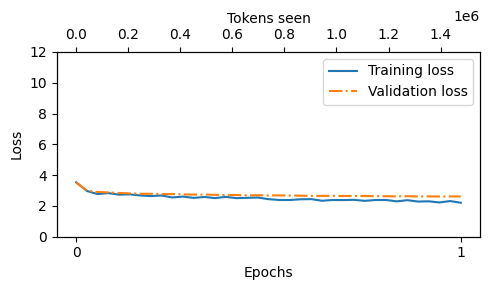

Saved cfg to /content/drive/MyDrive/llm-from-scratch-drive/output/gpt2_temp_continualpretrain_TEST_abstracts/epoch001_step0000737_cfg.json
Saved results to /content/drive/MyDrive/llm-from-scratch-drive/output/gpt2_temp_continualpretrain_TEST_abstracts/epoch001_step0000737_results.json
AFTER TRAINING:
FULL train loss: 2.252496832269963
FULL val loss: 2.595757388487095
Runtime: 00:23:32
{'initial_train_loss_full_set': 2.926077827205503, 'initial_val_loss_full_set': 2.9287627121297324, 'final_train_loss_full_set': 2.252496832269963, 'final_val_loss_full_set': 2.595757388487095, 'tokens_seen': 1476608, 'global_step': 737, 'runtime': '00:23:32'}


In [ ]:
model_after = run_training(cfg2)

### extract token embedding after training